# Variant 2 — Occluded / Built-in Fixture Visualization

Runs the trained **Variant 2** model (`mixed_moge2_live_v1`, MoGe-2 depth) on a few ARKit/Objectron
occluded fixtures (sink, bathtub, oven, stove, refrigerator). For each object it shows:
- the **input RGB crop** with the object mask,
- the **predicted 3D mesh** (metric, centered) with the **predicted W,H,D box (red)** and the **GT box (green)** drawn around it,
- a **predicted vs GT W,H,D** comparison.

Needs a free GPU (loads the SAM3D pipeline + MoGe-2).

In [1]:
import os, sys
os.environ.setdefault('LIDRA_SKIP_INIT', 'true')
REPO = '/mnt/source/sam-3d-objects'; OMNI = '/mnt/source/datasets_sam3d/OmniNOCS'
sys.path.insert(0, '/mnt/source/MoGe'); sys.path.insert(0, REPO); sys.path.insert(0, f'{REPO}/scripts')
import numpy as np, torch, matplotlib.pyplot as plt
from omegaconf import OmegaConf
from hydra.utils import instantiate
import sam3d_objects  # noqa
from eval_bbox_from_depth import MoGe2Estimator
from sam3d_objects.data.dataset.metric.omninocs import OmniNOCSObjectDataset

VARIANT2_CKPT = f'{REPO}/artifacts/metric_scale/checkpoints/mixed_moge2_live_v1_best.pt'
print('paths set')

/opt/conda/envs/sam3d/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


paths set


In [2]:
# --- Load Variant 2 pipeline + MoGe-2 (metric depth) ---
cfg = OmegaConf.load(f'{REPO}/checkpoints/hf/pipeline.yaml')
cfg.rendering_engine = 'pytorch3d'; cfg.compile_model = False
cfg.workspace_dir = f'{REPO}/checkpoints/hf'
cfg.metric_scale_checkpoint_path = VARIANT2_CKPT   # loads the trained head/decoder (Variant 2)
pipe = instantiate(cfg)
moge2 = MoGe2Estimator(device='cuda')
print('Variant 2 + MoGe-2 loaded')

2026-06-17 22:30:46.827 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA A100 80GB PCIe


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-06-17 22:30:47.951 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:51: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:100: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functional.py:166: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @_TORCH_CUSTOM_BWD
/opt/conda/envs/sam3d/lib/python3.11/site-packages/spconv/pytorch/functiona

[SPARSE][CONV] spconv algo: auto


2026-06-17 22:30:52.431 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-06-17 22:30:52.431 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-06-17 22:30:52.434 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
/mnt/source/MoGe/moge/model/v1.py:172: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-06-17 22:30:58.356 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-06-17 22:30:58.361 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - self.device: cuda
2026-0

Loading MoGe-2 ViT-L ...
MoGe-2 loaded.
Variant 2 + MoGe-2 loaded


In [3]:
# --- Faithfully load Variant 2's trained SLAT cross-attn ---
# The pipeline's metric_scale load only restores the head+decoder; Variant 2 also fine-tuned the
# SLAT cross-attention, so without this the predicted dims are NOT the true Variant 2 output.
from sam3d_objects.training.finetune_metric_scale import collect_slat_cross_attn_params
_ck = torch.load(VARIANT2_CKPT, map_location='cpu', weights_only=False)
if 'slat_cross_attn' in _ck:
    _, _bb = collect_slat_cross_attn_params(pipe, upcast_fp32=True)
    _sd = _ck['slat_cross_attn']
    for _i, _blk in enumerate(_bb.blocks):
        _ca = {k.split(f'blocks.{_i}.cross_attn.', 1)[1]: v for k, v in _sd.items() if k.startswith(f'blocks.{_i}.cross_attn.')}
        _n2 = {k.split(f'blocks.{_i}.norm2.', 1)[1]: v for k, v in _sd.items() if k.startswith(f'blocks.{_i}.norm2.')}
        if _ca: _blk.cross_attn.load_state_dict(_ca, strict=True)
        if _n2: _blk.norm2.load_state_dict(_n2, strict=True)
        _blk.cross_attn.eval(); _blk.norm2.eval()
    print(f'loaded Variant 2 SLAT cross-attn into {len(_bb.blocks)} blocks')
else:
    print('no slat_cross_attn in checkpoint (head+decoder only)')

Unfrozen SLAT cross-attn in 24 blocks (100,810,752 params across cross_attn + norm2) (cross_attn+norm2 upcast to fp32)
loaded Variant 2 SLAT cross-attn into 24 blocks


In [4]:
# --- helpers ---
def moge2_pointmap(rgb):
    pts = moge2.infer_points(rgb[..., :3].astype(np.uint8), np.eye(3))  # OpenCV metric, NaN-masked
    pts = pts.copy(); pts[..., 0] = -pts[..., 0]; pts[..., 1] = -pts[..., 1]  # -> PyTorch3D
    return torch.from_numpy(pts.astype(np.float32))

def run_object(rgb, mask):
    rgba = np.concatenate([rgb[..., :3], (mask.astype(np.uint8) * 255)[..., None]], -1)
    out = pipe.run(rgba, None, 42, stage1_only=False, with_mesh_postprocess=False,
                   with_texture_baking=False, with_layout_postprocess=False, use_vertex_color=True,
                   stage1_inference_steps=None, pointmap=moge2_pointmap(rgb), decode_formats=['mesh'])
    m = out['mesh']; m = m[0] if isinstance(m, (list, tuple)) else m
    v = (m.vertices.detach().float().cpu().numpy() if hasattr(m.vertices, 'detach') else np.asarray(m.vertices))
    md = out.get('metric_dimensions')                      # trained HEAD W,H,D (metres) = the red box
    if md is not None:
        pred_dims = md[0].float().cpu().numpy().reshape(-1)
    else:
        scale = out['scale'][0].float().cpu().numpy().reshape(-1)
        scale = scale if scale.size == 3 else np.repeat(scale[:1], 3)
        pred_dims = (v.max(0) - v.min(0)) * scale.mean()
    pred_desc = np.sort(pred_dims)[::-1]                    # W >= H >= D
    # Scale the canonical mesh to EXACTLY fill the head predicted box:
    # reorder mesh axes so its longest axis -> W, then stretch a unit box by the predicted dims.
    vc = v - (v.max(0) + v.min(0)) / 2.0
    order = np.argsort(vc.max(0) - vc.min(0))[::-1]         # mesh axes, longest first
    vp = vc[:, order]
    metric_verts = vp / (vp.max(0) - vp.min(0)) * pred_desc # fills the red box exactly
    return metric_verts, pred_desc

_EDGES = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
def box_lines(dims):
    w, h, d = np.asarray(dims) / 2.0
    c = np.array([[x*w, y*h, z*d] for x in (-1, 1) for y in (-1, 1) for z in (-1, 1)])
    return [[c[a], c[b]] for a, b in _EDGES]

def visualize(rgb, mask, metric_verts, pred_dims, gt_dims, title):
    from mpl_toolkits.mplot3d.art3d import Line3DCollection
    from matplotlib.patches import Rectangle
    fig = plt.figure(figsize=(14, 6))
    # --- left: FULL image, object tinted green + its 2D bbox ---
    ax1 = fig.add_subplot(121)
    disp = rgb[..., :3].copy().astype(np.uint8)
    disp[mask] = (0.55 * disp[mask] + 0.45 * np.array([0, 255, 0])).astype(np.uint8)
    ax1.imshow(disp)
    ys, xs = np.where(mask)
    ax1.add_patch(Rectangle((xs.min(), ys.min()), xs.max()-xs.min(), ys.max()-ys.min(),
                            fill=False, edgecolor='yellow', linewidth=2))
    ax1.set_title('full image (object in green)'); ax1.axis('off')
    # --- right: mesh scaled to HEAD dims, inside red pred box vs green GT box ---
    ax2 = fig.add_subplot(122, projection='3d')
    vv = metric_verts
    ax2.scatter(vv[:, 0], vv[:, 1], vv[:, 2], s=1, alpha=0.25, c='gray')
    ax2.add_collection3d(Line3DCollection(box_lines(pred_dims), colors='red', linewidths=1.8))
    ax2.add_collection3d(Line3DCollection(box_lines(gt_dims), colors='green', linewidths=1.8))
    r = max(gt_dims.max(), pred_dims.max()) / 2 * 1.25
    ax2.set_xlim(-r, r); ax2.set_ylim(-r, r); ax2.set_zlim(-r, r)
    ax2.set_box_aspect((1, 1, 1))
    ax2.set_title('mesh @ predicted dims  -  red = pred box, green = GT box')
    err = np.mean(np.abs(pred_dims - gt_dims) / np.clip(gt_dims, 1e-6, None)) * 100
    fig.suptitle(f"{title}  |  pred WHD {pred_dims.round(2)} m   vs   GT {gt_dims.round(2)} m   |  err {err:.0f}%")
    plt.tight_layout(); plt.show()
print('helpers ready')


helpers ready


In [5]:
# --- Reconstruct the EXACT heldout set the model was evaluated on (NOT training samples!) ---
# Run held out the LAST N records per source (NOCS 64 / Objectron 200 / ARKit 200), record-level,
# after the 5x size filter. Rebuild the dataset the same way, then take that heldout slice.
# NOTE: builds the full ~10k-record dataset (scans masks) -> a few minutes; the price of matching eval.
from collections import defaultdict, Counter
HELDOUT_PER_SRC = {'nocs_real275': 64, 'objectron': 200, 'arkitscenes': 200}
ds = OmniNOCSObjectDataset(
    omninocs_root=OMNI, sources=['nocs_real275', 'objectron', 'arkitscenes'],
    rgb_roots={'nocs_real275': f'{OMNI}/real_test', 'objectron': OMNI, 'arkitscenes': OMNI},
    split='train', max_records_per_source=3334, skip_missing_rgb=True)  # default 5x size filter ON
src_idx = defaultdict(list)
for _i, _r in enumerate(ds.records):
    src_idx[_r['source']].append(_i)
heldout_idx = []
for _src, _idxs in src_idx.items():
    heldout_idx += _idxs[len(_idxs) - HELDOUT_PER_SRC.get(_src, 0):]   # LAST n per source = heldout
print('heldout size:', len(heldout_idx))

# Pick occluded/hard fixtures actually present IN the heldout (rare -> broaden the list)
FIXTURES = {'sink', 'bathtub', 'oven', 'stove', 'refrigerator', 'cabinet', 'toilet',
            'television', 'shelves', 'table', 'machine', 'books'}
heldout_cats = Counter(ds.records[i]['category'] for i in heldout_idx)
print('fixture-ish categories in heldout:', {c: heldout_cats[c] for c in FIXTURES if heldout_cats[c]})
seen = Counter(); picks = []
for i in heldout_idx:
    c = ds.records[i]['category']
    if c in FIXTURES and seen[c] < 1:
        seen[c] += 1; picks.append(i)
    if len(picks) >= 6: break
print('selected', len(picks), 'HELDOUT fixtures:', [ds.records[i]['category'] for i in picks])


size-outlier filter (tol=±1.609 log, ~5.0x): dropped 2 of 10002 records [cabinet=1, cup=1]
heldout size: 464
fixture-ish categories in heldout: {'television': 13, 'machine': 2, 'sink': 4, 'oven': 6, 'shelves': 6, 'table': 29, 'toilet': 1, 'books': 29, 'stove': 3, 'refrigerator': 2, 'bathtub': 3, 'cabinet': 54}
selected 6 HELDOUT fixtures: ['books', 'table', 'cabinet', 'television', 'shelves', 'sink']


In [7]:
picks

[6638, 9800, 9801, 9802, 9808, 9841]

In [8]:
picks

[6638, 9800, 9801, 9802, 9808, 9841]

2026-06-17 22:31:33.728 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:673 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-06-17 22:31:33.729 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Running condition embedder ...
2026-06-17 22:31:33.885 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:645 - Condition embedder finishes!
2026-06-17 22:31:42.046 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:727 - Downsampled coords from 3908 to 3908
2026-06-17 22:31:42.096 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:457 - Rescaling scale by 1 after downsampling
2026-06-17 22:31:42.104 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:758 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-06-17 22:31:42.104 | INFO     | sam3d

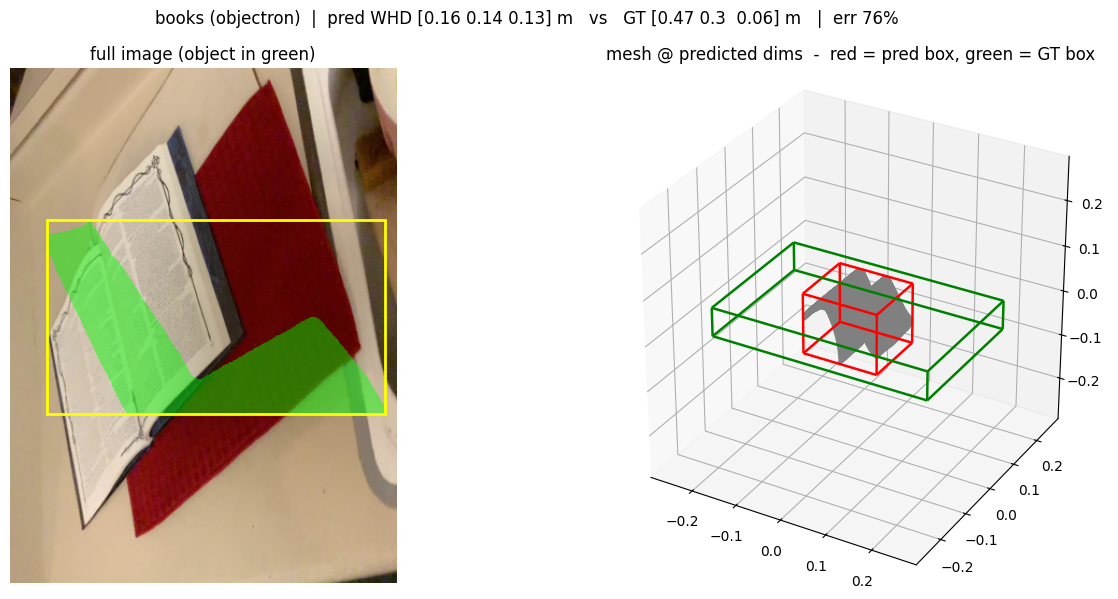

2026-06-17 22:31:53.836 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:673 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-06-17 22:31:53.837 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Running condition embedder ...
2026-06-17 22:31:53.968 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:645 - Condition embedder finishes!
2026-06-17 22:32:02.344 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:727 - Downsampled coords from 12263 to 12240
2026-06-17 22:32:02.352 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:457 - Rescaling scale by 1 after downsampling
2026-06-17 22:32:02.352 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:758 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-06-17 22:32:02.352 | INFO     | sam

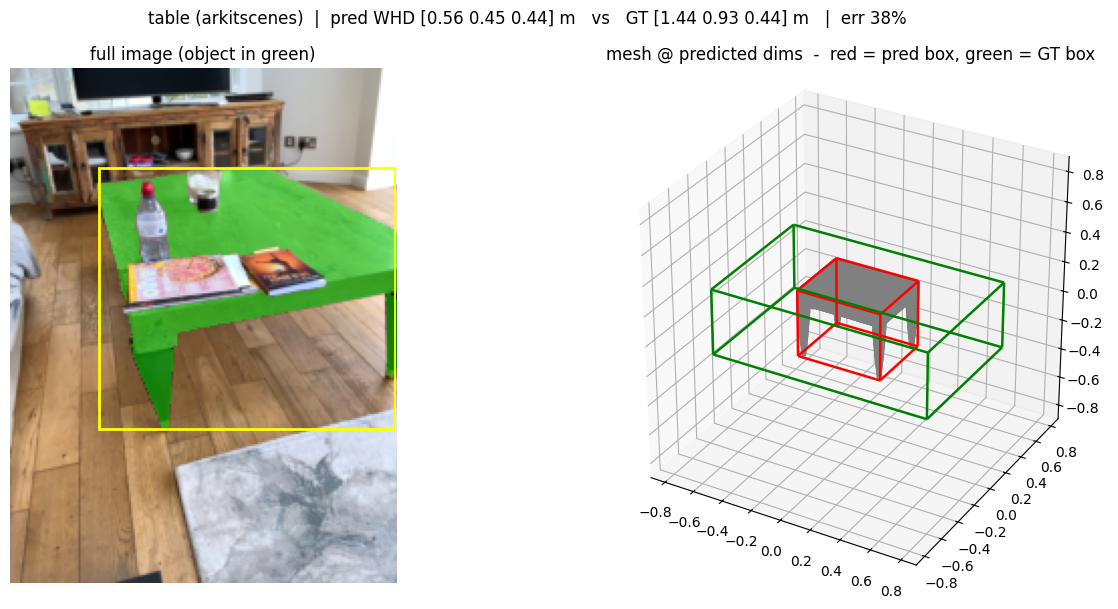

2026-06-17 22:32:13.819 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:673 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-06-17 22:32:13.820 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Running condition embedder ...
2026-06-17 22:32:13.950 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:645 - Condition embedder finishes!
2026-06-17 22:32:22.163 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:727 - Downsampled coords from 9295 to 9295
2026-06-17 22:32:22.198 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:457 - Rescaling scale by 1 after downsampling
2026-06-17 22:32:22.199 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:758 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-06-17 22:32:22.199 | INFO     | sam3d

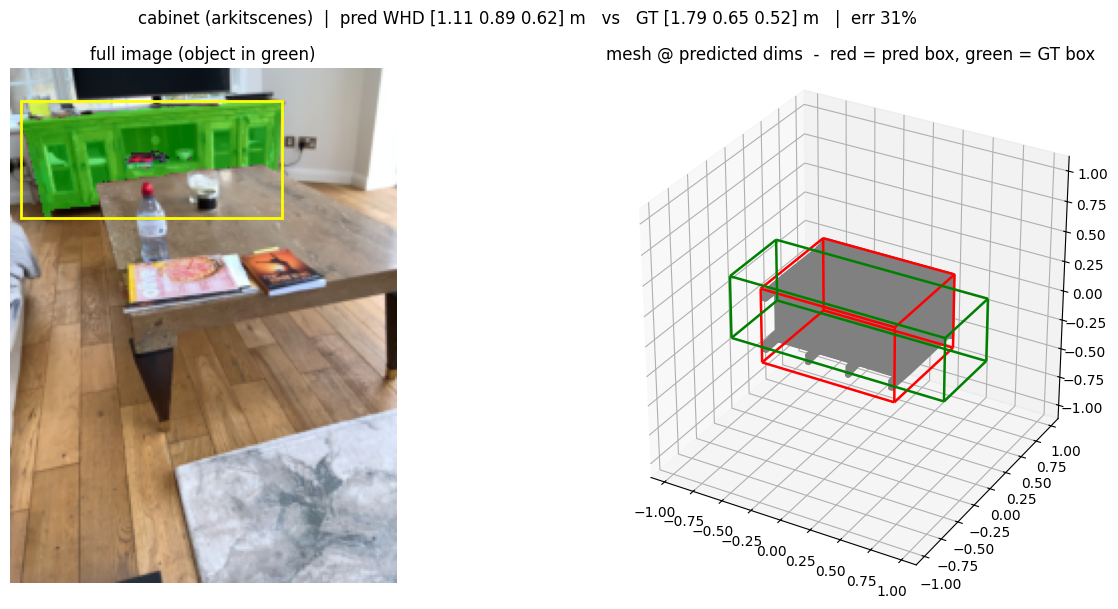

2026-06-17 22:32:31.875 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:673 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-06-17 22:32:31.876 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Running condition embedder ...
2026-06-17 22:32:32.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:645 - Condition embedder finishes!
2026-06-17 22:32:39.921 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:727 - Downsampled coords from 6590 to 6532
2026-06-17 22:32:39.956 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:457 - Rescaling scale by 1 after downsampling
2026-06-17 22:32:39.957 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:758 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-06-17 22:32:39.957 | INFO     | sam3d

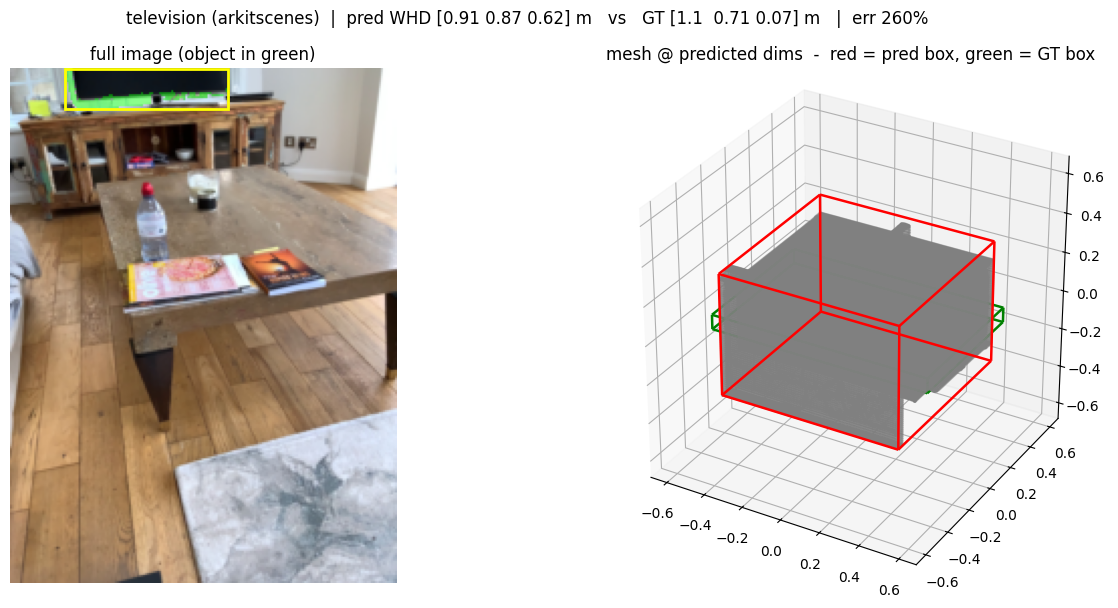

2026-06-17 22:32:48.055 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:673 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-06-17 22:32:48.056 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Running condition embedder ...
2026-06-17 22:32:48.186 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:645 - Condition embedder finishes!
2026-06-17 22:32:56.226 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:727 - Downsampled coords from 7473 to 7473
2026-06-17 22:32:56.261 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:457 - Rescaling scale by 1 after downsampling
2026-06-17 22:32:56.262 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:758 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-06-17 22:32:56.262 | INFO     | sam3d

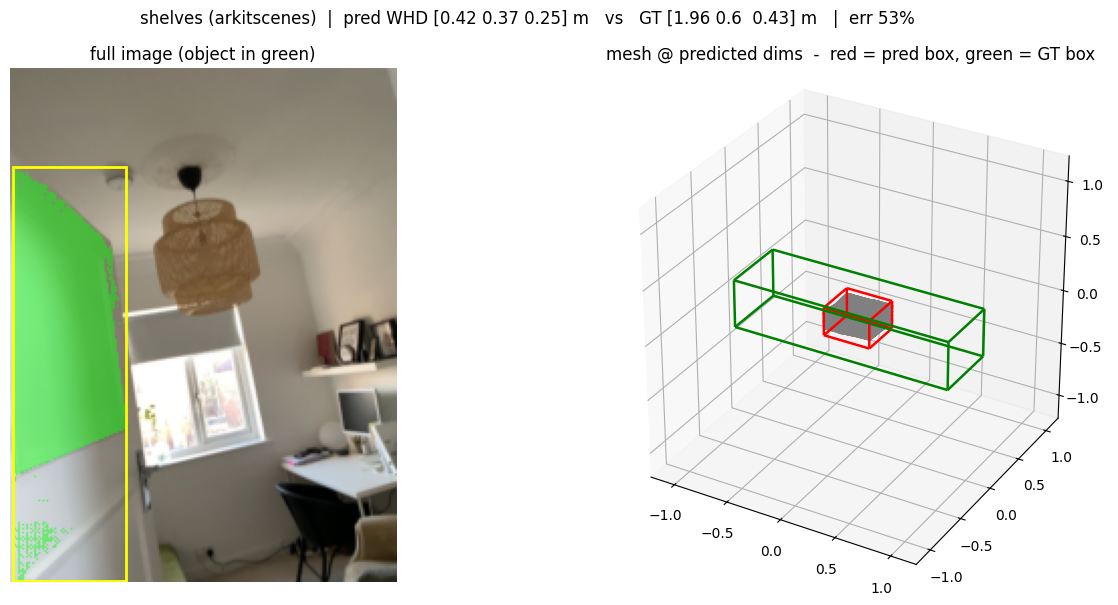

2026-06-17 22:33:04.075 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:673 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-06-17 22:33:04.076 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:641 - Running condition embedder ...
2026-06-17 22:33:04.205 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:645 - Condition embedder finishes!
2026-06-17 22:33:12.242 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:727 - Downsampled coords from 14442 to 13718
2026-06-17 22:33:12.277 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:457 - Rescaling scale by 1 after downsampling
2026-06-17 22:33:12.277 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:758 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-06-17 22:33:12.277 | INFO     | sam

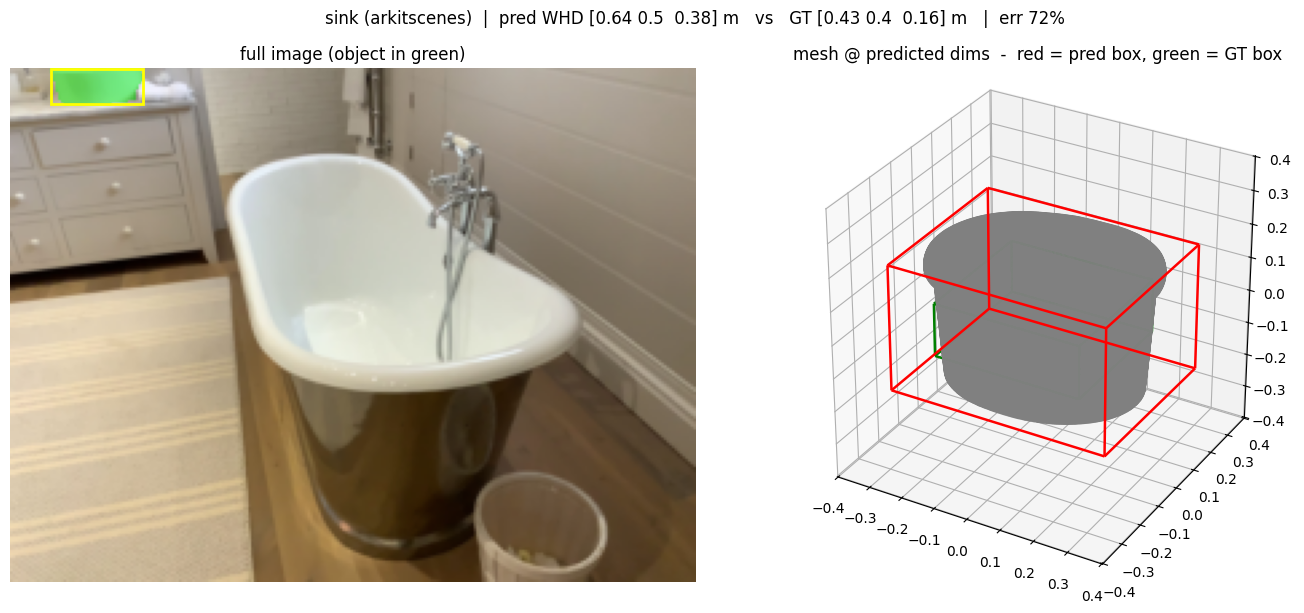

In [6]:
# --- run Variant 2 on each + visualize ---
for i in picks:
    item = ds[i]
    rgb = item['image'][..., :3]; mask = item['image'][..., 3] > 127
    gt_dims = np.sort(np.asarray(item['metric_dims'], dtype=np.float64))[::-1]
    try:
        verts, pred_dims = run_object(rgb, mask)
    except Exception as e:
        print(f"{item['category']}: FAILED ({type(e).__name__})"); continue
    visualize(rgb, mask, verts, pred_dims, gt_dims, f"{item['category']} ({item['source']})")

In [ ]:
0.11,0.13, 02.47